# **Time Allocation Patterns in the United States**

**Team member**: Qingyi Ren, Junqi Li, Zhanqi Li, Tzu-Ching Kuo
    
**Dataset**: [American Time Use Survey (ATUS), 2003–2021](https://docs.google.com/spreadsheets/d/1PlpKLPoT1ppbWohBSwybnGCEP7_mHLrv/edit?gid=1079022340#gid=1079022340)

---

## **1. Environment Setup & Data Import**  

**1.1. Load the libraries and import the raw dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_excel('American Time Use Survey.xlsx')
print(df.shape)
df.head()

(228455, 31)


,Year,SurveyID,Family Income,Housing Type,Age,Sex,Education Level,Employment Status,Occupation Type,Mins Caring for Household Members: All,...,Mins Leisure: Watching TV,Mins Personal Care,Mins Sleeping,Mins Purchasing Goods,Mins Civic and Religious Acitivites,Mins Religious and Spiritual Activities,Mins Volunteering,Mins Work Related Acitivities: All,Mins Work Related Activities: Traveling to Work,Mins Work Related Activities: Mins Working
0,2003,20030100013280,"$60,000 to $74,999",Own Home,60,Male,"Master's degree (MA, MS, MEng, MEd, MSW, etc.)",Employed,"Education, training, and library occupations",0,...,325,910,870,0,0,0,0,0,0,0
1,2003,20030100013344,Refused,Own Home,41,Female,Some college but no degree,Employed,Sales and related occupations,60,...,60,680,620,0,0,0,0,0,0,0
2,2003,20030100013352,"$75,000 to $99,999",Own Home,26,Female,Associate degree - occupational vocational,Employed,Personal care and service occupations,0,...,120,640,560,70,0,0,0,0,0,0
3,2003,20030100013848,"$20,000 to $24,999",Own Home,36,Female,High school graduate - diploma,Unemployed,NaN,5,...,265,755,720,0,0,0,0,120,0,0
4,2003,20030100014165,"$75,000 to $99,999",Own Home,51,Male,"Professional school degree (MD, DDS, DVM, etc.)",Employed,Healthcare practitioner and technical occupations,155,...,60,460,385,33,0,0,0,515,15,500


## **2. Data Exploration & Data Cleaning**

**2.1. Perform initial exploration of the dataset to understand its structure and content**

In [2]:
df.info()
df.describe()
print("Column names:")
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 228455 entries, 0 to 228454
Data columns (total 31 columns):
 #   Column                                                   Non-Null Count   Dtype
---  ------                                                   --------------   -----
 0   Year                                                     228455 non-null  int64
 1   SurveyID                                                 228455 non-null  int64
 2   Family Income                                            228455 non-null  str  
 3   Housing Type                                             228284 non-null  str  
 4   Age                                                      228455 non-null  int64
 5   Sex                                                      228455 non-null  str  
 6   Education Level                                          228455 non-null  str  
 7   Employment Status                                        228455 non-null  str  
 8   Occupation Type                              

**2.2. Identify Missing Values**

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

Occupation Type                                            87328
Housing Type                                                 171
Year                                                           0
Minutes Leisure: All Types                                     0
Mins Work Related Activities: Traveling to Work                0
Mins Work Related Acitivities: All                             0
Mins Volunteering                                              0
Mins Religious and Spiritual Activities                        0
Mins Civic and Religious Acitivites                            0
Mins Purchasing Goods                                          0
Mins Sleeping                                                  0
Mins Personal Care                                             0
Mins Leisure: Watching TV                                      0
Mins Leisure: Sports and Exercise                              0
Mins Leisure: Socializing                                      0
Mins Leisure: Arts and En

**2.2 Clean and preprocess the dataset to improve data quality**

- Remove invalid responses in income (e.g., Refused, Don't know, Blank)  
- Drop columns with excessive missing values (Occupation Type)  
- Fill missing values in Housing Type using the most frequent category

In [4]:
df_clean = df.copy()

df_clean = df_clean[~df_clean['Family Income'].isin(['Refused', "Don't know", 'Blank'])].copy()

df_clean = df_clean.drop(columns=['Occupation Type'])

df_clean['Housing Type'] = df_clean['Housing Type'].fillna(
    df_clean['Housing Type'].mode()[0]
)

## **3. Feature Engineering**

**3.1 Create income groups**

- Group detailed income ranges into broader categories (Low, Lower-Mid, Upper-Mid, High)  
- Simplify analysis and improve comparability across income levels

In [5]:
income_group_map = {
    'Less than $5,000': 'Low (<$20K)',
    '$5,000 to $7,499': 'Low (<$20K)',
    '$7,500 to $9,999': 'Low (<$20K)',
    '$10,000 to $12,499': 'Low (<$20K)',
    '$12,500 to $14,999': 'Low (<$20K)',
    '$15,000 to $19,999': 'Low (<$20K)',

    '$20,000 to $24,999': 'Lower-Mid ($20K–$50K)',
    '$25,000 to $29,999': 'Lower-Mid ($20K–$50K)',
    '$30,000 to $34,999': 'Lower-Mid ($20K–$50K)',
    '$35,000 to $39,999': 'Lower-Mid ($20K–$50K)',
    '$40,000 to $49,999': 'Lower-Mid ($20K–$50K)',

    '$50,000 to $59,999': 'Upper-Mid ($50K–$100K)',
    '$60,000 to $74,999': 'Upper-Mid ($50K–$100K)',
    '$75,000 to $99,999': 'Upper-Mid ($50K–$100K)',

    '$100,000 to $149,999': 'High (>$100K)',
    '$150,000 and over': 'High (>$100K)',
}

df_clean['Income Group'] = df_clean['Family Income'].map(income_group_map)


**3.2 Temporal Segmentation**  

- Split data into Pre-COVID (≤2019) and COVID period (2020–2021) 

In [6]:
df_clean['Period'] = df_clean['Year'].apply(
    lambda x: 'Pre-COVID (≤2019)' if x <= 2019 else 'COVID (2020–2021)'
)


**3.3 Validate cleaned dataset**  

- Check dataset shape after cleaning  
- Verify missing values are handled  
- Examine distribution of income groups and time periods

In [7]:
print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values per column:")
print(df_clean.isnull().sum().sort_values(ascending=False).head(10))

print("\nCount per income group:")
print(df_clean['Income Group'].value_counts())

print("\nCount per period:")
print(df_clean['Period'].value_counts())

df_clean.head()

Cleaned dataset shape: (214757, 32)

Missing values per column:
Year                                               0
SurveyID                                           0
Income Group                                       0
Mins Work Related Activities: Mins Working         0
Mins Work Related Activities: Traveling to Work    0
Mins Work Related Acitivities: All                 0
Mins Volunteering                                  0
Mins Religious and Spiritual Activities            0
Mins Civic and Religious Acitivites                0
Mins Purchasing Goods                              0
dtype: int64

Count per income group:
Income Group
Upper-Mid ($50K–$100K)    68510
Lower-Mid ($20K–$50K)     68263
High (>$100K)             39986
Low (<$20K)               37998
Name: count, dtype: int64

Count per period:
Period
Pre-COVID (≤2019)    196888
COVID (2020–2021)     17869
Name: count, dtype: int64


,Year,SurveyID,Family Income,Housing Type,Age,Sex,Education Level,Employment Status,Mins Caring for Household Members: All,Mins Caring for Household Members: Adults,...,Mins Sleeping,Mins Purchasing Goods,Mins Civic and Religious Acitivites,Mins Religious and Spiritual Activities,Mins Volunteering,Mins Work Related Acitivities: All,Mins Work Related Activities: Traveling to Work,Mins Work Related Activities: Mins Working,Income Group,Period
0,2003,20030100013280,"$60,000 to $74,999",Own Home,60,Male,"Master's degree (MA, MS, MEng, MEd, MSW, etc.)",Employed,0,0,...,870,0,0,0,0,0,0,0,Upper-Mid ($50K–$100K),Pre-COVID (≤2019)
2,2003,20030100013352,"$75,000 to $99,999",Own Home,26,Female,Associate degree - occupational vocational,Employed,0,0,...,560,70,0,0,0,0,0,0,Upper-Mid ($50K–$100K),Pre-COVID (≤2019)
3,2003,20030100013848,"$20,000 to $24,999",Own Home,36,Female,High school graduate - diploma,Unemployed,5,0,...,720,0,0,0,0,120,0,0,Lower-Mid ($20K–$50K),Pre-COVID (≤2019)
4,2003,20030100014165,"$75,000 to $99,999",Own Home,51,Male,"Professional school degree (MD, DDS, DVM, etc.)",Employed,155,0,...,385,33,0,0,0,515,15,500,Upper-Mid ($50K–$100K),Pre-COVID (≤2019)
5,2003,20030100014169,"$40,000 to $49,999",Own Home,32,Female,"Bachelor's degree (BA, AB, BS, etc.)",Employed,245,0,...,675,0,0,0,0,0,0,0,Lower-Mid ($20K–$50K),Pre-COVID (≤2019)


## **4. Exploratory Data Analysis**

**4.1 Select key activity categories**

- Focus on 6 core daily activities (Work, Leisure, Household, Exercise, TV, Sleep)  
- Simplify analysis by selecting representative time-use variables
- Arrange income groups in logical order for comparison

In [8]:
key_act_cols = {
    'Work': 'Mins Work Related Activities: Mins Working',
    'Leisure': 'Minutes Leisure: All Types',
    'Household': 'Mins Household Activities: All',
    'Exercise': 'Mins Leisure: Sports and Exercise',
    'TV': 'Mins Leisure: Watching TV',
    'Sleep': 'Mins Sleeping'
}


income_order = [
    'Low (<$20K)',
    'Lower-Mid ($20K–$50K)',
    'Upper-Mid ($50K–$100K)',
    'High (>$100K)'
]

**4.2 Calculate average time allocation by income group**

- Compute mean daily hours for each activity by income group  
- Convert minutes to hours for better interpretation  

In [10]:
income_means = (
    df_clean
    .groupby('Income Group')[[v for v in key_act_cols.values()]]
    .mean()
    .loc[income_order]  
    / 60
)

income_means.columns = list(key_act_cols.keys())

print("Average daily hours for each activity by income group:")
print(income_means.round(2))

Average daily hours for each activity by income group:
                        Work  Leisure  Household  Exercise    TV  Sleep
Income Group                                                           
Low (<$20K)             1.38     6.63       2.03      0.20  3.91   9.35
Lower-Mid ($20K–$50K)   2.44     5.75       2.08      0.25  3.17   8.94
Upper-Mid ($50K–$100K)  3.04     5.10       2.09      0.33  2.54   8.65
High (>$100K)           3.23     4.74       2.05      0.41  2.16   8.54


**4.3 Visualize time allocation across income groups**

- Use bar chart to compare activity patterns across income levels  
- Highlight differences in work, leisure, and sleep distribution  

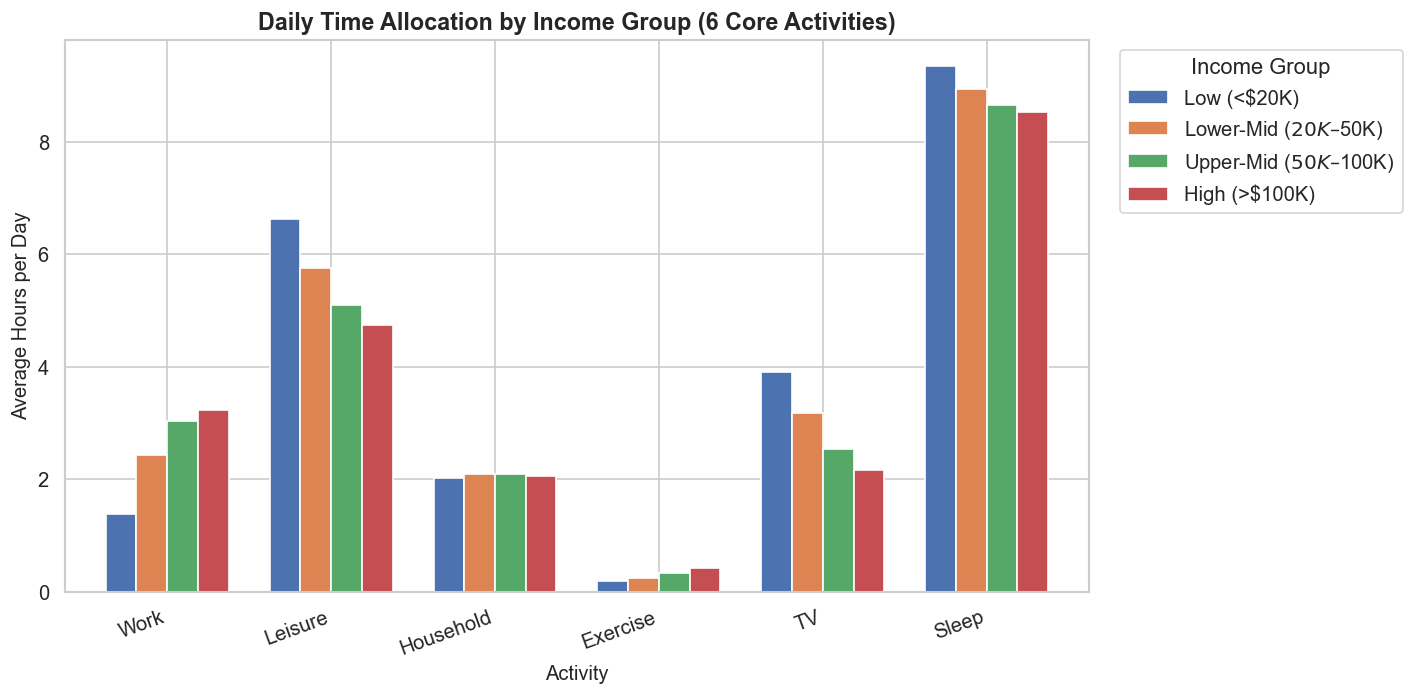

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

income_means.T.plot(
    kind='bar',
    ax=ax,
    width=0.75,
    edgecolor='white'
)

ax.set_title('Daily Time Allocation by Income Group (6 Core Activities)', fontsize=14, fontweight='bold')
ax.set_xlabel('Activity', fontsize=12)
ax.set_ylabel('Average Hours per Day', fontsize=12)
ax.legend(title='Income Group', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

## **5. Key Q1:COVID comparison**

> How did daily time allocation patterns change before and during the COVID-19 pandemic?

**5.1 Compare time allocation before and during COVID-19**

- Split dataset into Pre-COVID and COVID periods  
- Calculate average hours for each activity  
- Measure changes to identify shifts in daily behavior  

In [12]:
pre_covid = df_clean[df_clean['Period'] == 'Pre-COVID (≤2019)']
covid = df_clean[df_clean['Period'] == 'COVID (2020–2021)']

pre_means = pre_covid[[v for v in key_act_cols.values()]].mean() / 60
covid_means = covid[[v for v in key_act_cols.values()]].mean() / 60

pre_means.index = list(key_act_cols.keys())
covid_means.index = list(key_act_cols.keys())

period_comparison = pd.DataFrame({
    'Pre-COVID': pre_means,
    'COVID': covid_means,
    'Change (hours)': (covid_means - pre_means)
})

print("Average daily hours before and during COVID:")
print(period_comparison.round(2))

Average daily hours before and during COVID:
           Pre-COVID  COVID  Change (hours)
Work            2.61   2.43           -0.18
Leisure         5.48   5.84            0.35
Household       2.05   2.28            0.23
Exercise        0.29   0.33            0.04
TV              2.88   3.28            0.40
Sleep           8.83   9.06            0.23


**5.2 Visualize differences between Pre-COVID and COVID**

- Compare average hours for each activity  
- Annotate changes to highlight increases or decreases  

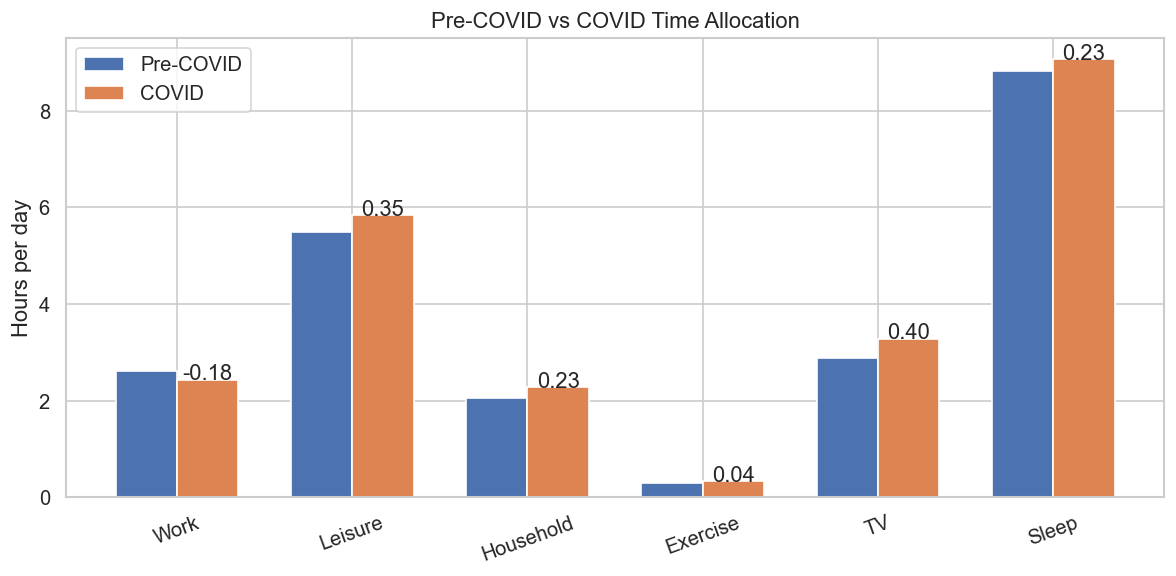

In [13]:
x = np.arange(len(key_act_cols))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, pre_means.values, width, label='Pre-COVID')

plt.bar(x + width/2, covid_means.values, width, label='COVID')

for i in range(len(key_act_cols)):
    diff = covid_means.values[i] - pre_means.values[i]
    
    plt.text(
        x[i] + width/2,
        covid_means.values[i],
        f'{diff:.2f}',
        ha='center'
    )

plt.xticks(x, list(key_act_cols.keys()), rotation=20)
plt.ylabel('Hours per day')
plt.title('Pre-COVID vs COVID Time Allocation')
plt.legend()

plt.tight_layout()
plt.show()

**5.3 Analyze yearly trends of work time by income group**

- Track changes in work hours over time  
- Highlight COVID period to observe disruptions 

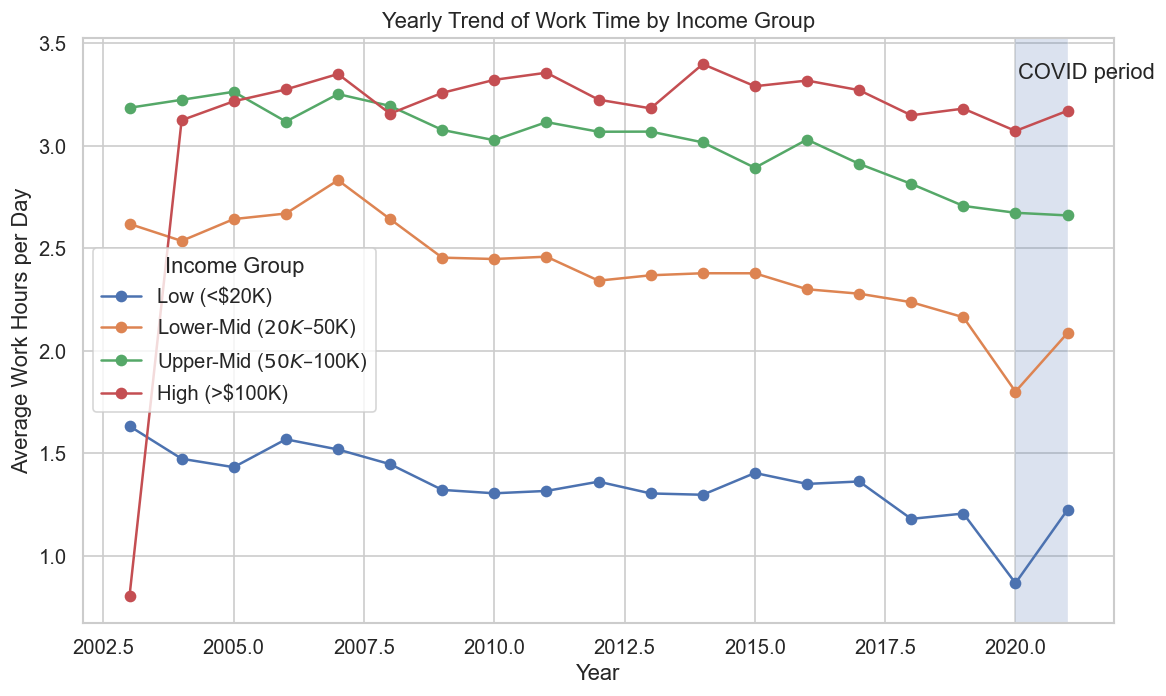

In [14]:
work_col = 'Mins Work Related Activities: Mins Working'

year_income_work = (
    df_clean
    .groupby(['Year', 'Income Group'])[work_col]
    .mean()
    .reset_index()
)

year_income_work['Work Hours'] = year_income_work[work_col] / 60

income_order = [
    'Low (<$20K)',
    'Lower-Mid ($20K–$50K)',
    'Upper-Mid ($50K–$100K)',
    'High (>$100K)'
]

plt.figure(figsize=(10, 6))

for group in income_order:
    temp = year_income_work[year_income_work['Income Group'] == group]
    plt.plot(temp['Year'], temp['Work Hours'], marker='o', label=group)

plt.axvspan(2020, 2021, alpha=0.2)

y_max = year_income_work['Work Hours'].max()
plt.text(2020.05, y_max * 0.98, 'COVID period')

plt.title('Yearly Trend of Work Time by Income Group')
plt.xlabel('Year')
plt.ylabel('Average Work Hours per Day')
plt.legend(title='Income Group')

plt.tight_layout()
plt.show()

**5.4 Perform statistical tests on time allocation changes**

- Use t-tests to compare Pre-COVID and COVID periods  
- Calculate effect size (Cohen’s d) to measure magnitude of change

In [15]:
def cohens_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    pooled_std = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    if pooled_std == 0:
        return np.nan
    return (y.mean() - x.mean()) / pooled_std

stats_results = []

for act_name, col in key_act_cols.items():
    pre_vals = pre_covid[col]
    covid_vals = covid[col]

    t_stat, p_val = stats.ttest_ind(pre_vals, covid_vals, equal_var=False)
    d = cohens_d(pre_vals, covid_vals)

    stats_results.append({
        'Activity': act_name,
        'Pre Mean (hrs)': pre_vals.mean() / 60,
        'COVID Mean (hrs)': covid_vals.mean() / 60,
        'Change (hrs)': (covid_vals.mean() - pre_vals.mean()) / 60,
        't-statistic': t_stat,
        'p-value': p_val,
        'Cohen_d': d
    })

stats_df = pd.DataFrame(stats_results).sort_values(by='Change (hrs)', key=np.abs, ascending=False)

print("Statistical comparison: Pre-COVID vs COVID")
display(stats_df.round(4))

Statistical comparison: Pre-COVID vs COVID


,Activity,Pre Mean (hrs),COVID Mean (hrs),Change (hrs),t-statistic,p-value,Cohen_d
4,TV,2.8785,3.2786,0.4001,-15.9861,0.0,0.1345
1,Leisure,5.4824,5.8373,0.3549,-11.9469,0.0,0.0959
5,Sleep,8.8259,9.0577,0.2318,-13.3633,0.0,0.1026
2,Household,2.0501,2.2759,0.2258,-11.6349,0.0,0.0951
0,Work,2.6054,2.4291,-0.1763,5.7206,0.0,-0.0441
3,Exercise,0.2911,0.3321,0.0411,-5.7192,0.0,0.0441


**5.5 Compare time allocation by income group and period**

- Examine how COVID impacts differ across income groups  
- Focus on key activities for clearer comparison  

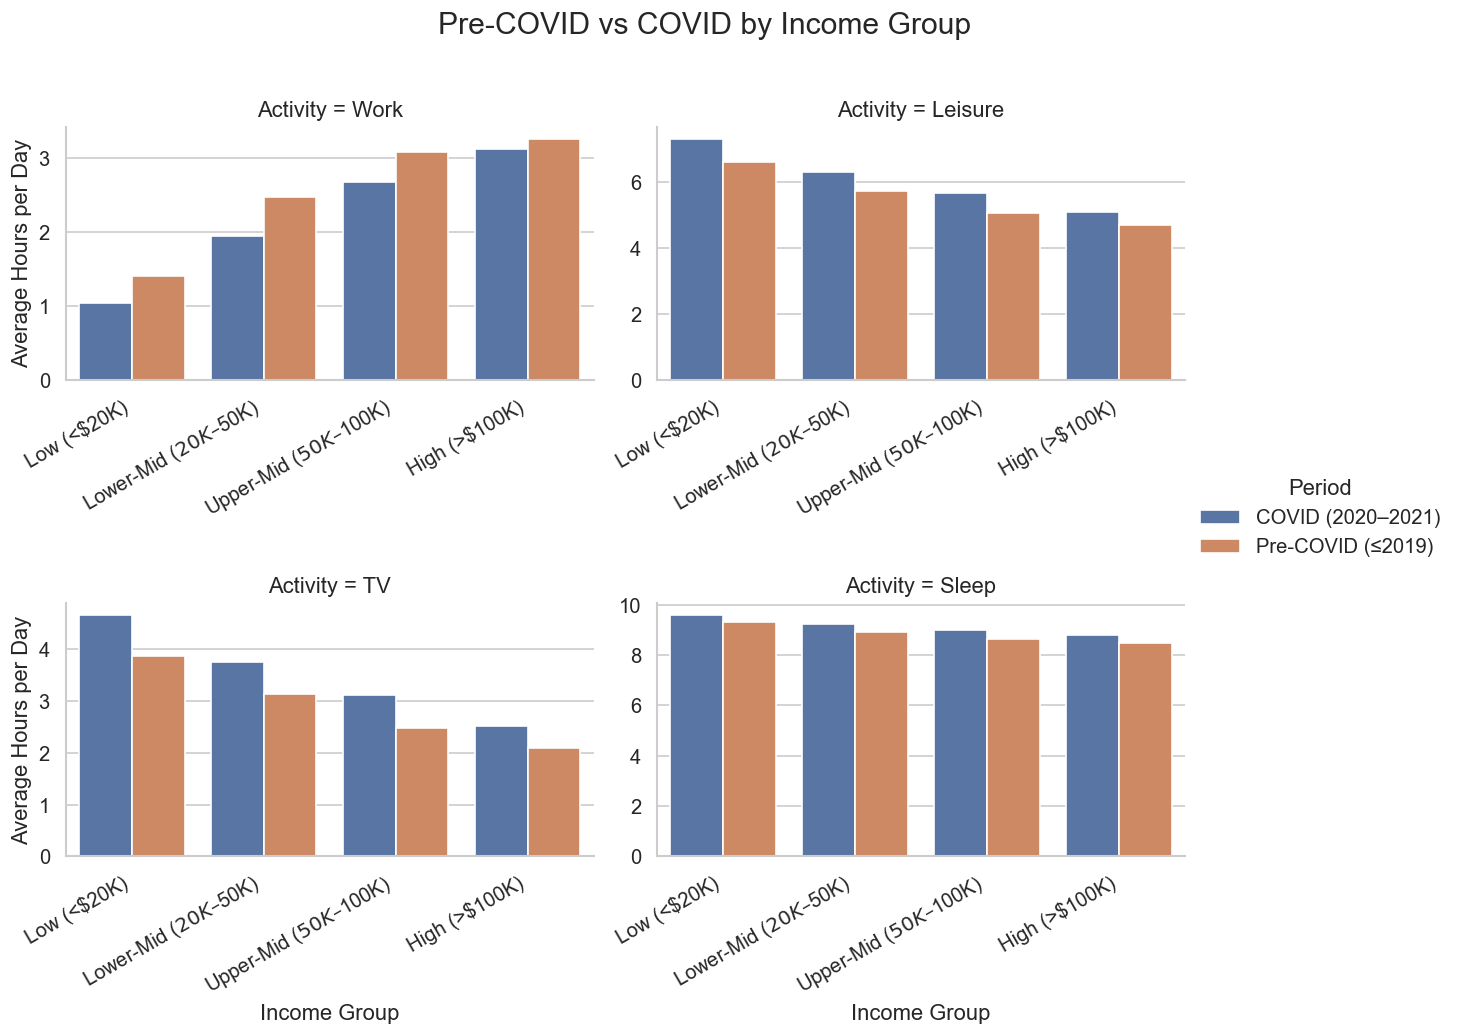

In [16]:
group_period_means = (
    df_clean
    .groupby(['Income Group', 'Period'])[[v for v in key_act_cols.values()]]
    .mean()
    .reset_index()
)

group_period_means['Income Group'] = pd.Categorical(
    group_period_means['Income Group'],
    categories=income_order,
    ordered=True
)

plot_df = group_period_means.melt(
    id_vars=['Income Group', 'Period'],
    value_vars=list(key_act_cols.values()),
    var_name='Activity Column',
    value_name='Minutes'
)

reverse_act_cols = {v: k for k, v in key_act_cols.items()}
plot_df['Activity'] = plot_df['Activity Column'].map(reverse_act_cols)
plot_df['Hours'] = plot_df['Minutes'] / 60


focus_acts = ['Work', 'Leisure', 'TV', 'Sleep']
plot_df_focus = plot_df[plot_df['Activity'].isin(focus_acts)]

g = sns.catplot(
    data=plot_df_focus,
    x='Income Group',
    y='Hours',
    hue='Period',
    col='Activity',
    kind='bar',
    col_wrap=2,
    height=4,
    aspect=1.3,
    sharey=False
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', labelbottom=True)
    ax.set_xticks(range(4))  
    ax.set_xticklabels(
        ['Low (<$20K)', 'Lower-Mid ($20K–$50K)', 'Upper-Mid ($50K–$100K)', 'High (>$100K)'], 
        rotation=30, ha='right'
    )
    

g.set_axis_labels("Income Group", "Average Hours per Day")
g.fig.suptitle("Pre-COVID vs COVID by Income Group")

g.fig.subplots_adjust(top=0.86, bottom=0.10, wspace=0.12, hspace=0.88)
g.fig.suptitle("Pre-COVID vs COVID by Income Group", fontsize=18)

plt.show()

**5.6 Estimate the effect of COVID using regression**

- Use OLS regression to measure COVID impact on each activity  
- Control for age, gender, employment status, and income group  

In [18]:
df_model = df_clean.copy()

df_model['COVID'] = (df_model['Year'] >= 2020).astype(int)

df_model = df_model.rename(columns={
    'Mins Work Related Activities: Mins Working': 'work_mins',
    'Minutes Leisure: All Types': 'leisure_mins',
    'Mins Household Activities: All': 'household_mins',
    'Mins Leisure: Sports and Exercise': 'exercise_mins',
    'Mins Leisure: Watching TV': 'tv_mins',
    'Mins Sleeping': 'sleep_mins'
})

outcome_vars = ['work_mins', 'leisure_mins', 'household_mins', 'exercise_mins', 'tv_mins', 'sleep_mins']

X_base = df_model[['COVID', 'Age']].copy()

X_cat = pd.get_dummies(
    df_model[['Sex', 'Employment Status', 'Income Group']],
    drop_first=True
)

X = pd.concat([X_base, X_cat], axis=1)

X.insert(0, 'Intercept', 1)

X = X.astype(float)

regression_results = []

for outcome in outcome_vars:
    y = df_model[outcome].astype(float).values
    X_mat = X.values

    # OLS: beta = (X'X)^(-1) X'y
    beta = np.linalg.lstsq(X_mat, y, rcond=None)[0]

    y_pred = X_mat @ beta

    # R-squared
    ss_total = np.sum((y - y.mean()) ** 2)
    ss_resid = np.sum((y - y_pred) ** 2)
    r_squared = 1 - ss_resid / ss_total

    covid_idx = list(X.columns).index('COVID')
    covid_coef = beta[covid_idx]

    regression_results.append({
        'Outcome': outcome,
        'COVID Coef (mins)': covid_coef,
        'R-squared': r_squared
    })

regression_df = pd.DataFrame(regression_results)

print("Regression results: effect of COVID after controls")
display(regression_df.round(4))

Regression results: effect of COVID after controls


,Outcome,COVID Coef (mins),R-squared
0,work_mins,-0.9912,0.2578
1,leisure_mins,13.9708,0.1555
2,household_mins,7.4314,0.0554
3,exercise_mins,1.5678,0.0225
4,tv_mins,21.1532,0.1305
5,sleep_mins,19.1136,0.0392


**5.7 Analyze heterogeneous effects across income groups**

- Add interaction terms between COVID and income group  
- Examine whether COVID impacts differ by income level  

In [19]:
interaction_results = []

for outcome in outcome_vars:
    X_base = df_model[['COVID', 'Age']].copy()

    X_cat = pd.get_dummies(
        df_model[['Sex', 'Employment Status', 'Income Group']],
        drop_first=True
    )

    income_dummy_cols = [col for col in X_cat.columns if col.startswith('Income Group_')]

    X_interaction = pd.DataFrame(index=df_model.index)
    for col in income_dummy_cols:
        X_interaction[f'COVID_x_{col}'] = df_model['COVID'] * X_cat[col]

    X = pd.concat([X_base, X_cat, X_interaction], axis=1)
    X.insert(0, 'Intercept', 1)
    X = X.astype(float)
    y = df_model[outcome].astype(float).values
    X_mat = X.values

    beta = np.linalg.lstsq(X_mat, y, rcond=None)[0]
    y_pred = X_mat @ beta

    ss_total = np.sum((y - y.mean()) ** 2)
    ss_resid = np.sum((y - y_pred) ** 2)
    r_squared = 1 - ss_resid / ss_total

    coef_series = pd.Series(beta, index=X.columns)

    base_covid_effect = coef_series.get('COVID', np.nan)

    interaction_term_names = [col for col in X.columns if col.startswith('COVID_x_')]
    interaction_term_values = coef_series[interaction_term_names]

    interaction_results.append({
        'Outcome': outcome,
        'Base COVID Effect': base_covid_effect,
        'Interaction Terms Found': len(interaction_term_names),
        'Max Interaction Effect': interaction_term_values.max() if len(interaction_term_values) > 0 else np.nan,
        'Min Interaction Effect': interaction_term_values.min() if len(interaction_term_values) > 0 else np.nan,
        'Model R-squared': r_squared
    })

interaction_df = pd.DataFrame(interaction_results)

print("Interaction model summary")
display(interaction_df.round(4))

Interaction model summary


,Outcome,Base COVID Effect,Interaction Terms Found,Max Interaction Effect,Min Interaction Effect,Model R-squared
0,work_mins,0.6250,3,1.3163,-5.8715,0.2578
1,leisure_mins,15.4539,3,6.0122,-3.7888,0.1555
2,household_mins,11.5471,3,-3.7917,-11.4491,0.0555
3,exercise_mins,3.7637,3,-1.5767,-4.0902,0.0225
4,tv_mins,18.2265,3,14.3109,2.0121,0.1305
5,sleep_mins,18.6755,3,2.8153,-3.0186,0.0392


***

## **6. Key Q2:Income Group Prediction**

> Can daily time allocation patterns predict a person's income group?

**6.1 Define features and target for classification**

- Use time allocation variables as features (X)  
- Use income group as the target variable (y)  

In [20]:
# Define features (X) and target (y)
feature_cols = [
    'work_mins',
    'leisure_mins',
    'household_mins',
    'exercise_mins',
    'tv_mins',
    'sleep_mins'
]

X = df_model[feature_cols].copy()
y = df_model['Income Group'].copy()

# Check shapes
print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature shape: (214757, 6)
Target distribution:
Income Group
Upper-Mid ($50K–$100K)    68510
Lower-Mid ($20K–$50K)     68263
High (>$100K)             39986
Low (<$20K)               37998
Name: count, dtype: int64


**6.2 Split data into training and testing sets**

- Split the dataset into training and testing subsets  
- Use stratified sampling to preserve income group distribution  

In [21]:
from sklearn.model_selection import train_test_split

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # maintain class distribution
)

# Check shapes
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (171805, 6)
Test shape: (42952, 6)

Train target distribution:
Income Group
Upper-Mid ($50K–$100K)    0.319013
Lower-Mid ($20K–$50K)     0.317860
High (>$100K)             0.186194
Low (<$20K)               0.176933
Name: proportion, dtype: float64

Test target distribution:
Income Group
Upper-Mid ($50K–$100K)    0.319007
Lower-Mid ($20K–$50K)     0.317866
High (>$100K)             0.186185
Low (<$20K)               0.176942
Name: proportion, dtype: float64


#### **Logistic Regression**

**6.3 Train Logistic Regression model**

- Use Logistic Regression as a baseline classification model  
- Predict income groups based on time allocation features  
- Evaluate model performance on the test set  

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
LogisticRegression(max_iter=5000)

# Train model
log_model.fit(X_train, y_train)

# Predictions
y_pred = log_model.predict(X_test)

# Evaluation
accuracy_log = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_log)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

/opt/homebrew/Caskroom/miniforge/base/envs/usableai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.355606258148631

Classification Report:
                        precision    recall  f1-score   support

         High (>$100K)       0.14      0.00      0.00      7997
           Low (<$20K)       0.40      0.04      0.07      7600
 Lower-Mid ($20K–$50K)       0.35      0.50      0.41     13653
Upper-Mid ($50K–$100K)       0.36      0.59      0.45     13702

              accuracy                           0.36     42952
             macro avg       0.31      0.28      0.23     42952
          weighted avg       0.32      0.36      0.29     42952


Confusion Matrix:
[[  16   40 2615 5326]
 [  18  311 4581 2690]
 [  40  291 6867 6455]
 [  43  141 5438 8080]]


***Insight***
>    
> - Logistic Regression shows **moderate performance** (~35% accuracy)  
> 
> - The model **struggles to distinguish extreme income groups (Low and High)**  
>   - This suggests that time allocation patterns alone may not strongly separate all income levels  
>       

**6.4 Visualize classification performance with confusion matrix**

- Show how predictions compare to true labels  
- Identify which income groups are often confused  

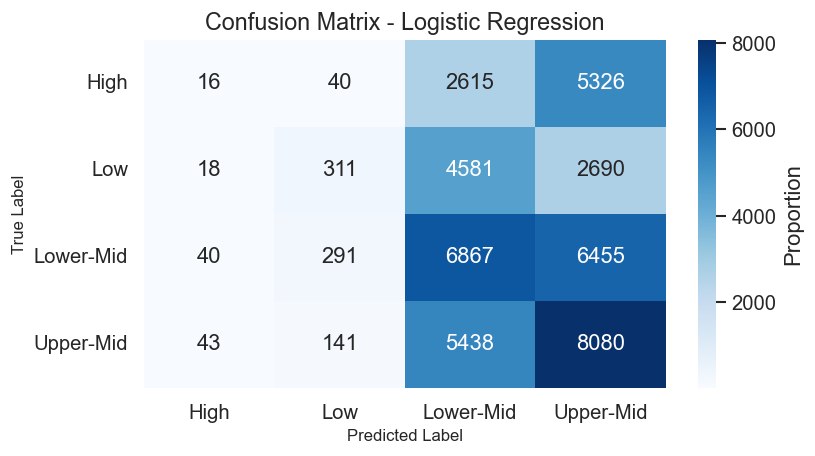

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Short labels
labels = ['High', 'Low', 'Lower-Mid', 'Upper-Mid']

plt.figure(figsize=(7, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Proportion'}
)

plt.xlabel("Predicted Label", fontsize=10)
plt.ylabel("True Label", fontsize=10)
plt.title("Confusion Matrix - Logistic Regression", fontsize=14)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**6.5 Interpret feature influence using Logistic Regression coefficients**

- Use model coefficients to understand how each activity relates to income groups  
- Identify which behaviors are positively or negatively associated with each group  
- Visualize coefficients to compare patterns across income levels  

<Figure size 1440x960 with 0 Axes>

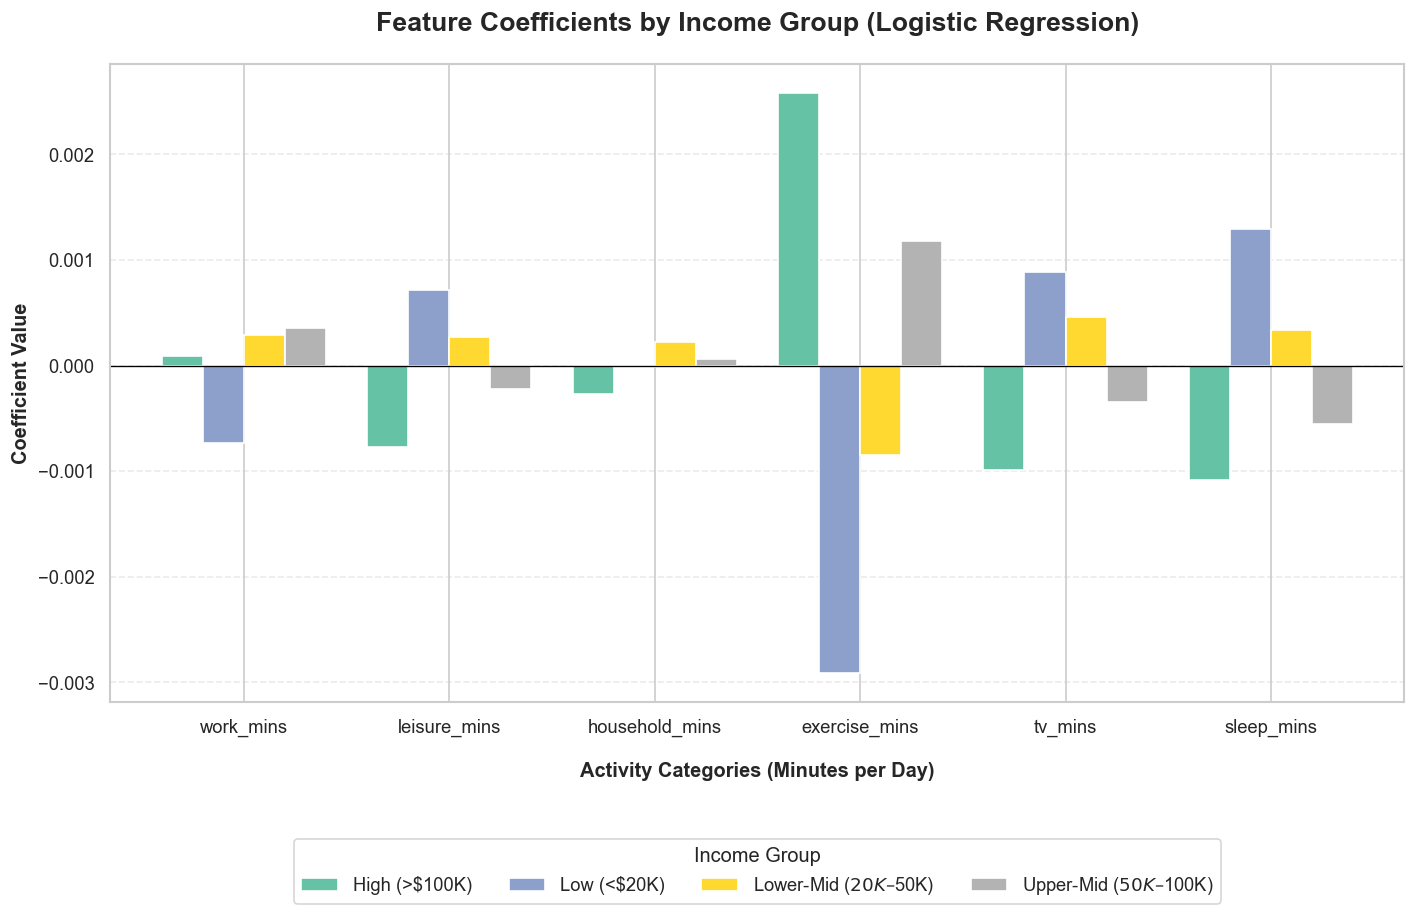

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create coefficient dataframe
coef_df = pd.DataFrame(
    log_model.coef_,
    columns=feature_cols,
    index=log_model.classes_
)

# Transpose so features are on x-axis
coef_df_T = coef_df.T

# Set style
sns.set_style("whitegrid")

# Plot
plt.figure(figsize=(12, 8))
ax = coef_df_T.plot(
    kind='bar',
    width=0.8,
    colormap='Set2',
    figsize=(12, 8)
)

# Title and labels
plt.title(
    "Feature Coefficients by Income Group (Logistic Regression)",
    fontsize=16,
    weight='bold',
    pad=20
)

plt.ylabel("Coefficient Value", fontsize=12, weight='bold')
plt.xlabel("Activity Categories (Minutes per Day)", fontsize=12, weight='bold', labelpad=15)

# Improve ticks readability
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

# Add zero line for reference
plt.axhline(0, color='black', linewidth=0.8)

# Add grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Better legend placement
plt.legend(
    title="Income Group",
    ncol=4,
    fontsize=11,
    title_fontsize=12,
    frameon=True,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2)
)

plt.tight_layout()
plt.show()

***Insight***
>  
> - **Exercise** is positively associated with **higher income groups** and negatively associated with lower income  
> 
> - **TV time and sleep** are more associated with **lower income groups**  
>   
> - Middle-income groups show weaker and less distinct patterns  
> 
> - Overall, behavioral differences across income levels are present but not sharply separated  

#### **Random Forest**

**6.6 Train a Random Forest model**

- Use Random Forest to capture non-linear relationships  
- Evaluate model accuracy and prediction patterns  

In [44]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.3199152542372881

Classification Report:
                        precision    recall  f1-score   support

         High (>$100K)       0.25      0.18      0.21      7997
           Low (<$20K)       0.27      0.19      0.22      7600
 Lower-Mid ($20K–$50K)       0.34      0.39      0.36     13653
Upper-Mid ($50K–$100K)       0.34      0.41      0.37     13702

              accuracy                           0.32     42952
             macro avg       0.30      0.29      0.29     42952
          weighted avg       0.31      0.32      0.31     42952


Confusion Matrix:
[[1430  626 2464 3477]
 [ 673 1425 3229 2273]
 [1502 1885 5294 4972]
 [2041 1349 4720 5592]]


**6.7 Visualize Random Forest performance with confusion matrix**

- Compare predictions from Random Forest with true labels  

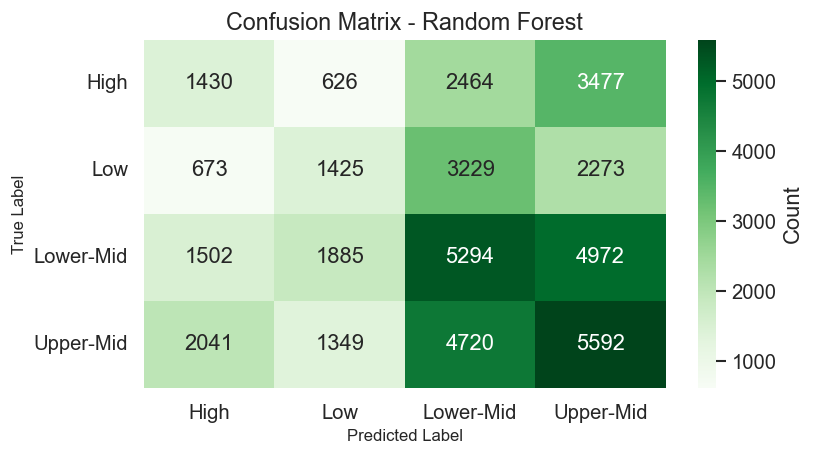

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix (Random Forest)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Same label order
labels = ['High', 'Low', 'Lower-Mid', 'Upper-Mid']

plt.figure(figsize=(7, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',  # 用整數（比比例更直觀）
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Count'}
)

plt.xlabel("Predicted Label", fontsize=10)
plt.ylabel("True Label", fontsize=10)
plt.title("Confusion Matrix - Random Forest", fontsize=14)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

***Insight*** 
>   
> - Random Forest **improves the identification of extreme groups (Low and High)**, but with **lower overall accuracy** (~32%)  
> 
> - This suggests a trade-off between stability and flexibility in model behavior  
> 
> - Overall, time allocation patterns alone may not be sufficient to strongly predict income group  

**6.8 Feature importance from Random Forest**

- Measure the relative importance of each activity in predicting income groups  
- Identify which features contribute most to model decisions  

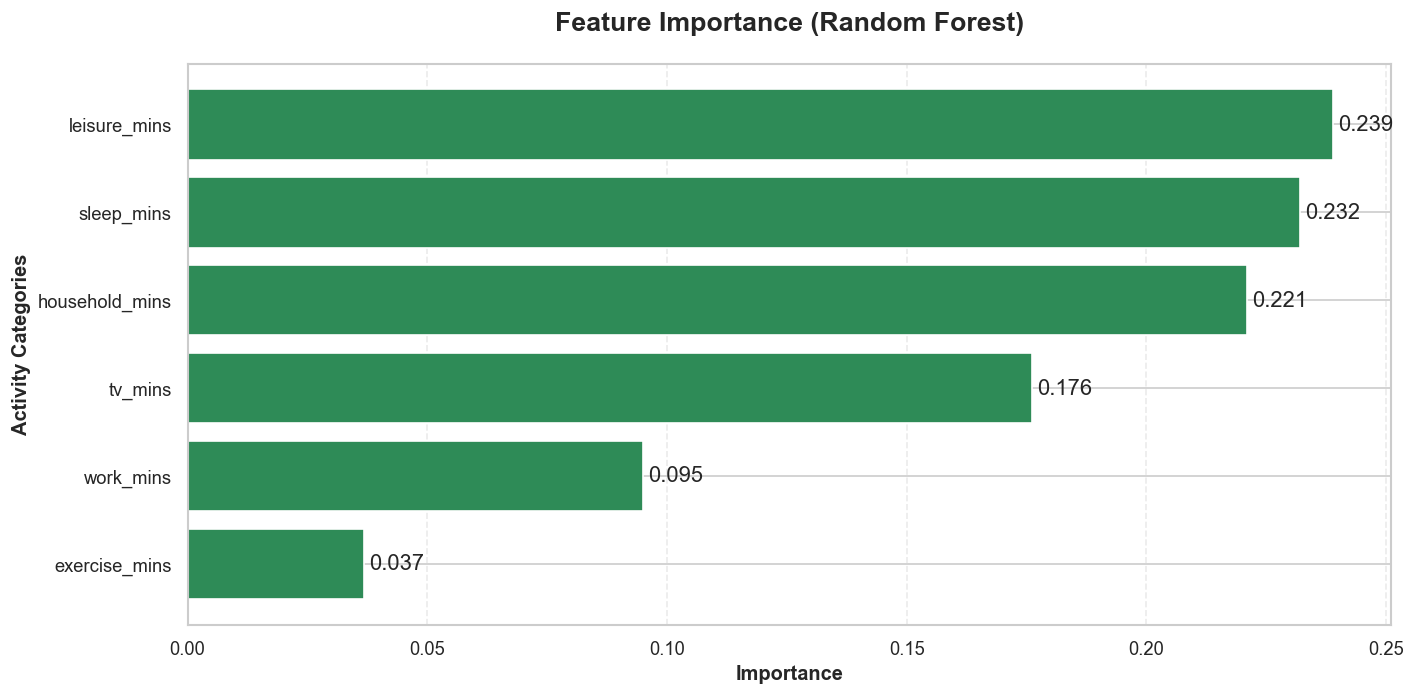

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
importances = rf_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
})

# Sort by importance
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

# Set style
sns.set_style("whitegrid")

# Plot
plt.figure(figsize=(12, 6))

bars = plt.barh(
    feat_imp_df['Feature'],
    feat_imp_df['Importance'],
    color='seagreen'
)

# Title and labels
plt.title(
    "Feature Importance (Random Forest)",
    fontsize=16,
    weight='bold',
    pad=20
)

plt.xlabel("Importance", fontsize=12, weight='bold')
plt.ylabel("Activity Categories", fontsize=12, weight='bold')

# Improve ticks
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Add grid
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Add values on bars
for i, v in enumerate(feat_imp_df['Importance']):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.show()

***Insight***
> 
> - **Leisure time and sleep** are the most important features for predicting income group  
>   
> - Work time is less important than expected -> suggesting that differences in working hours are not the primary driver of income classification  
>    
> - TV time also plays a significant role, indicating that how individuals spend their leisure time is informative  
> - **Exercise has the lowest importance** ->  suggesting it contributes less to distinguishing income groups  
>
> - Overall, the results suggest that **patterns of free time usage are more predictive of income than work-related activities**  

#### **Q2 Key Insight**
  
**Income groups are not clearly separable based on time allocation alone**

- Logistic Regression achieves higher accuracy but tends to classify most individuals into middle-income groups  
- Random Forest is more flexible and captures extreme groups better, but with lower overall accuracy

---

## **7. Lifestyle Clustering Analysis**

Previous classification models (Logistic Regression and Random Forest) showed limited ability to predict income groups from time allocation patterns  
-> This suggests that differences in daily activities across income groups may not be clearly separable  

Instead of forcing individuals into predefined income categories, we further explore whether natural lifestyle groups exist in the data by K-means clustering to identify groups of individuals with similar daily routines  

-> This allows us to examine how these patterns relate to income groups  

**7.1 Data preparation for clustering**

- Use time allocation variables as features for clustering  
- Standardize features to ensure equal contribution across variables  

In [59]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features (same as Q2)
cluster_features = feature_cols

X_cluster = df_model[cluster_features].copy()

# Standardize 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

**7.2 Apply K-means clustering**

- Use K-means to group individuals based on similar activity patterns  
- Assign each individual to a cluster representing a lifestyle group  

In [60]:
# Choose number of clusters
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
df_model['Cluster'] = clusters

**7.3 Cluster interpretation**

- Examine average time allocation within each cluster  
- Identify distinct lifestyle patterns based on activity distributions  

In [61]:
cluster_summary = df_model.groupby('Cluster')[feature_cols].mean() / 60
cluster_summary.round(2)

,work_mins,leisure_mins,household_mins,exercise_mins,tv_mins,sleep_mins
Cluster,,,,,,
0,0.26,4.37,3.46,0.18,1.89,9.56
1,8.43,2.76,0.88,0.16,1.46,7.62
2,0.20,10.03,1.17,0.59,5.93,9.00


**7.4 Relationship between clusters and income groups**

- Compare cluster membership with income group distribution  
- Evaluate whether lifestyle patterns align with socioeconomic status  

In [62]:
cluster_income = pd.crosstab(df_model['Cluster'], df_model['Income Group'], normalize='index')
cluster_income.round(2)

Income Group,High (>$100K),Low (<$20K),Lower-Mid ($20K–$50K),Upper-Mid ($50K–$100K)
Cluster,,,,
0,0.19,0.18,0.31,0.32
1,0.23,0.10,0.30,0.37
2,0.13,0.26,0.35,0.27


***Insight***
>   
>- These clusters represent meaningful behavioral patterns in daily time allocation
>   - **Cluster 0**: **Household-oriented** lifestyle with low work and high household activities  
>
>   - **Cluster 1**: **Work-intensive** lifestyle with long working hours and limited leisure  
>
>   - **Cluster 2**: **Leisure-dominant** lifestyle with high TV and free time  
>      
> 
> - However, **income groups are distributed across all clusters** rather than concentrated in specific ones  
>   - This indicates that **lifestyle patterns do not map directly to income levels**  
> 
> - While certain trends exist (e.g., work-heavy individuals are more likely to have higher income), the relationship is not strong  
>   - Overall, lifestyle differences exist independently of income classification  

**7.5 Visualizing lifestyle patterns across clusters**

- Visualize the average daily time allocation for each cluster  
- Each cluster is labeled based on its dominant activity patterns to improve interpretability  

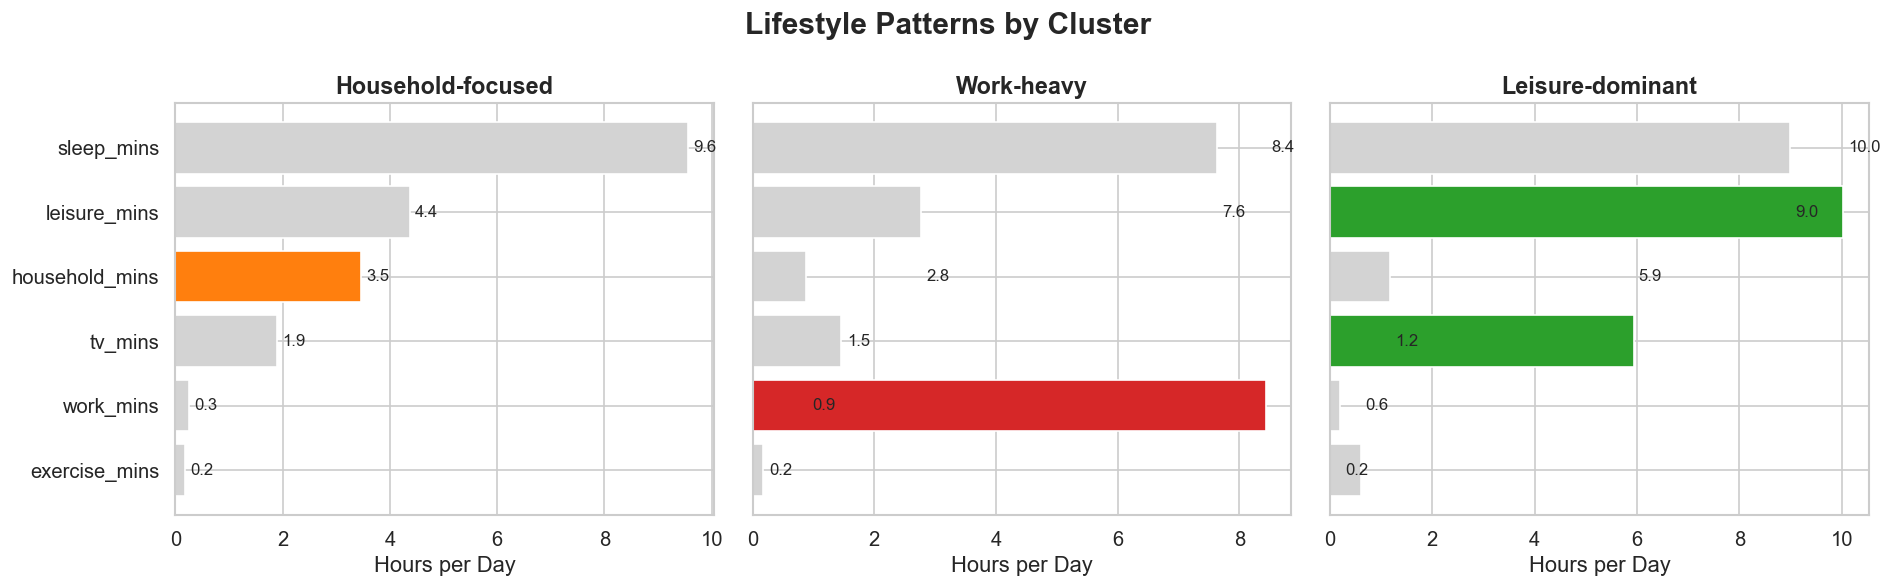

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Cluster naming
cluster_names = {
    0: "Household-focused",
    1: "Work-heavy",
    2: "Leisure-dominant"
}

# Already in hours
cluster_summary_hours = cluster_summary

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for i, cluster in enumerate(cluster_summary_hours.index):
    data = cluster_summary_hours.loc[cluster]

    # Highlight key activities
    colors = []
    for feature in data.index:
        if cluster == 1 and feature == 'work_mins':
            colors.append('#d62728')  # red
        elif cluster == 2 and feature in ['leisure_mins', 'tv_mins']:
            colors.append('#2ca02c')  # green
        elif cluster == 0 and feature == 'household_mins':
            colors.append('#ff7f0e')  # orange
        else:
            colors.append('#d3d3d3')  # light gray

    # Sort for readability
    data_sorted = data.sort_values()

    # Plot
    axes[i].barh(data_sorted.index, data_sorted.values, color=[colors[data.index.get_loc(f)] for f in data_sorted.index])

    axes[i].set_title(cluster_names[cluster], fontsize=14, weight='bold')
    axes[i].set_xlabel("Hours per Day")

    # Add value labels
    for j, v in enumerate(data_sorted.values):
        axes[i].text(v + 0.1, j, f"{v:.1f}", va='center', fontsize=10)

# Global title
plt.suptitle("Lifestyle Patterns by Cluster", fontsize=18, weight='bold')

plt.tight_layout()
plt.show()